In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import h5py
import sys, glob
sys.path.append('../')
import analysis_utils as utils

from scipy.optimize import curve_fit
from scipy.special import erf
from scipy.signal import decimate

yale_colors = ['#00356b', '#286dc0', '#63aaff', '#4a4a4a']
utils.load_plotting_setting()

from matplotlib.gridspec import GridSpec

In [2]:
import importlib
importlib.reload(utils)

<module 'analysis_utils' from 'c:\\Users\\yuhan\\dm_nanospheres\\analysis_notebooks\\..\\analysis_utils.py'>

In [3]:
def get_pulse_area(tt, dd):
    # Time in s, drive signal in V
    noise = np.mean(dd[tt < -0.5e-7])
    area = np.trapz(dd-noise, x=tt)
    
    return area

def process_pulse_waveforms(files):
    tt = None
    dds, aas = [], []
    for file in files:
        data = np.genfromtxt(file, delimiter=',', skip_header=1)
        _tt, _dd = data.T[0], data.T[1]
        _aa = get_pulse_area(_tt, _dd)

        if tt is None:
            tt = _tt

        dds.append(_dd)
        aas.append([_aa])

    return tt, dds, aas

In [4]:
from scipy.special import erf

def gaus(x, x0, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-1 * (x - x0)**2 / (2 * sigma**2))

def search_expectation(x0, alpha, amp2kev, sig_amp):
    sigma = sig_amp * amp2kev
    bias = alpha * sigma

    first = bias * 0.5 * ( erf((bias - x0)/(np.sqrt(2) * sigma)) - erf((-1 * bias - x0)/(np.sqrt(2) * sigma)) )

    xx0 = np.linspace(bias, x0 + 5*sigma, 1000)
    second = np.trapz(gaus(xx0, x0, sigma) * np.abs(xx0), xx0, axis=0)

    xx1 = np.linspace(x0 - 5*sigma, -1 * bias, 1000)
    third = np.trapz(gaus(xx1, x0, sigma) * np.abs(xx1), xx1, axis=0)

    return (first + second + third) / amp2kev

## Frist calculate the size of applied impulse

Assume 138 V/m when 1 V is applied to the trapping lens. Everything else is grounded. Will need to check the actual pulse shape agrees with previous measurement.

In [ ]:
pulse_amps_1e = np.asarray([12, 34, 57, 80, 103, 127, 150, 174])

In [ ]:
folder = r'E:\pulse_waveform\20241204_quantum_composers'
# folder = r'/Volumes/LaCie/pulse_waveform/20241204_quantum_composers'
# folder = r'/Users/yuhan/work/nanospheres/data/pulse_waveform/20241204_quantum_composers'

tt = None
dds_mean, dds_std, aas_mean, aas_std = [], [], [], []

for dataset in ['2_5v', '5v', '7_5v', '10v', '12_5v', '15v', '17_5v', '20v']:
    files = glob.glob(os.path.join(folder, f'{dataset}/C3_*.CSV'))
    _tt, dds, aas = process_pulse_waveforms(files)
    
    mean = np.mean(dds, axis=0)
    std = np.std(dds, axis=0)

    aa_mean = np.mean(aas)
    aa_std  = np.std(aas)

    if tt is None:
        tt = _tt

    dds_mean.append(mean)
    aas_mean.append(aa_mean)
    dds_std.append(std)
    aas_std.append(aa_std)

<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\p'
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_28304/2156215370.py:14: SyntaxWarning: invalid escape sequence '\D'
  ax.set_title(f'$\Delta p$ = {int(amp_kev)} $\pm$ {amp_kev_std:.2f} keV', fontsize=10)
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_28304/2156215370.py:14: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title(f'$\Delta p$ = {int(amp_kev)} $\pm$ {amp_kev_std:.2f} keV', fontsize=10)


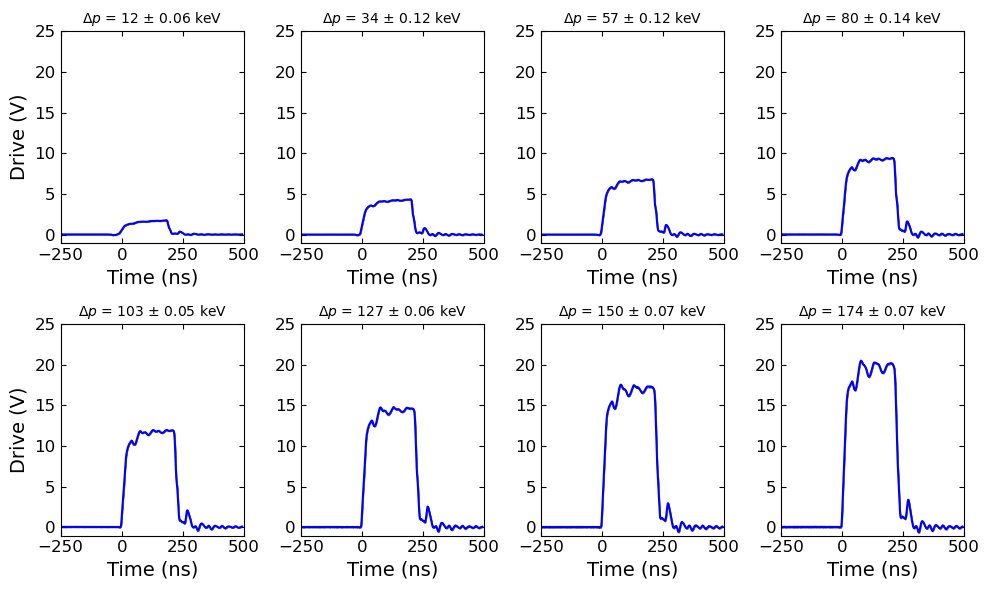

In [ ]:
charge = 1
efield = 138 # V/m

fig, axes = plt.subplots(2, 4, figsize=(10, 6))
for i in range(8):
    ax = axes.flatten()[i]

    amp_kev = charge * aas_mean[i] * efield * 1.602e-19 * utils.SI2ev / 1000
    amp_kev_std = charge * aas_std[i] * efield * 1.602e-19 * utils.SI2ev / 1000
    
    ax.fill_between(tt*1e9, dds_mean[i]-dds_std[i], dds_mean[i]+dds_std[i], color='grey', alpha=0.95)
    ax.plot(tt*1e9, dds_mean[i], color='blue')
    
    ax.set_title(f'$\Delta p$ = {int(amp_kev)} $\pm$ {amp_kev_std:.2f} keV', fontsize=10)

    ax.set_xlim(-250, 500)
    ax.set_ylim(-1, 25)
    
    if i == 0 or i == 4:
        ax.set_ylabel('Drive (V)')

    ax.set_xlabel('Time (ns)')

fig.tight_layout()



## Large pulse calibration

Charge up the sphere to approximately 128e (there is a relatively large, ~15% uncertainty here) and apply impulses

The reconstruction remains approximately linear up to ~20 MeV, but the resolution is broadened by an unknown mechanism.

In [ ]:
outfile_name = 'sphere_20250406_calibration_unnormalized_amps_20250410_4_7.h5py'
out_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data'
# out_dir = r'C:\Users\yuhan\dm_nanospheres\data_processed\sphere_data'

unnormalized_amps_all_flattened = []

fout = h5py.File(os.path.join(out_dir, outfile_name), 'r')
g = fout['processed_amplitudes']
for v in [2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]:
    unnormalized_amps_all_flattened.append(g[f'unnormalized_amps_{v}v'][:])
unnormalized_amps_all_sphere_20250406 = unnormalized_amps_all_flattened

unnormalized_amps_noise_flattened = g['unnormalized_amps_noise_5v'][:]
unnormalized_amps_noise_nosearch_flattened = g['unnormalized_amps_noise_nosearch_5v'][:]

fout.close()

bins = np.arange(0, 25000, 50) / 7055.26352068

hhs, bcs, gps = utils.fit_amps_gaus(unnormalized_amps_all_flattened, bins=bins, noise=False, return_bins=False)
hh_noise, be_noise = np.histogram(unnormalized_amps_noise_flattened, bins=bins)
hh_noise_nosearch, be_noise_nosearch, gps_nosearch = utils.fit_amps_gaus([unnormalized_amps_noise_nosearch_flattened], bins=bins, noise=False, return_bins=False)

(0.0, 25000.0)

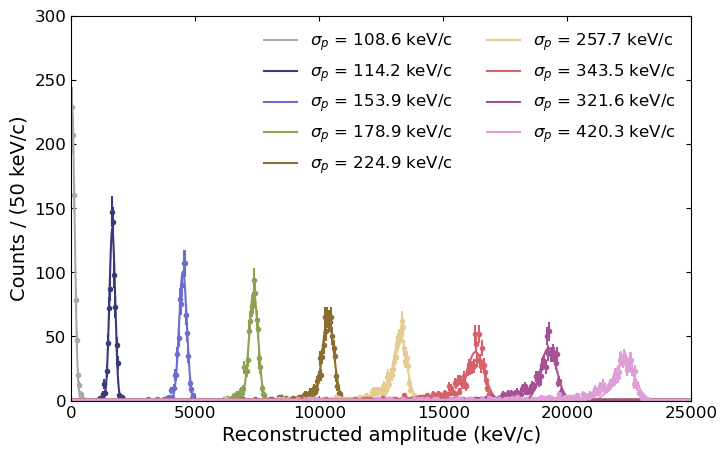

In [ ]:
pulseamps = pulse_amps_1e * 128

xx = np.linspace(0, np.max(bcs[0]), 1000)
amp2kev_all = pulseamps[-1] / gps[7][1]

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.colormaps.get_cmap('tab20b').resampled(8).colors

ax.errorbar(bcs[0]*amp2kev_all, hh_noise_nosearch[0], yerr=np.sqrt(hh_noise_nosearch[0]), fmt='.', color='darkgrey')
ax.plot(xx*amp2kev_all, utils.gauss(xx, *gps_nosearch[0]), label=fr'$\sigma_p$ = {gps_nosearch[0][2]*amp2kev_all:.1f} keV/c', color='darkgrey')

for i in range(8):
    ax.errorbar(bcs[0]*amp2kev_all, hhs[i], yerr=np.sqrt(hhs[i]), fmt='.', color=colors[i])
    ax.plot(xx*amp2kev_all, utils.gauss(xx, *gps[i]), color=colors[i], label=fr'$\sigma_p$ = {gps[i][2]*amp2kev_all:.1f} keV/c')

ax.legend(frameon=False, ncol=2)

ax.set_xlabel(r'Reconstructed amplitude (keV/c)')
ax.set_ylabel(fr'Counts / ({(bcs[0][1] - bcs[0][0]) * amp2kev_all:.0f} keV/c)')

ax.set_ylim(0, 300)
ax.set_xlim(0, 25000)


In [ ]:
pulseamps / np.asarray(gps).T[1]

array([6560.57078805, 6814.94057417, 7003.51729372, 6978.25081057,
       7018.18086291, 7036.65892647, 7041.13901425, 7055.26352068])

Discharge the sphere to 8e and were able to reproduce the ~150 keV resolution, giving us some confidence that the above calibration is not very off.

In [ ]:
outfile_name = 'sphere_20250406_calibration_unnormalized_amps_20250411_0_3.h5py'
# out_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data'
out_dir = r'C:\Users\yuhan\dm_nanospheres\data_processed\sphere_data'

unnormalized_amps_all_flattened = []

fout = h5py.File(os.path.join(out_dir, outfile_name), 'r')
g = fout['processed_amplitudes']
for v in [2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]:
    unnormalized_amps_all_flattened.append(g[f'unnormalized_amps_{v}v'][:])
unnormalized_amps_all_sphere_20250406 = unnormalized_amps_all_flattened

unnormalized_amps_noise_flattened = g['unnormalized_amps_noise_5v'][:]
unnormalized_amps_noise_nosearch_flattened = g['unnormalized_amps_noise_nosearch_5v'][:]

fout.close()

bins = np.arange(0, 6000, 50) / 7042.25563485

hhs, bcs, gps = utils.fit_amps_gaus(unnormalized_amps_all_flattened, bins=bins, noise=False, return_bins=False)
hh_noise, be_noise = np.histogram(unnormalized_amps_noise_flattened, bins=bins)
hh_noise_nosearch, be_noise_nosearch, gps_nosearch = utils.fit_amps_gaus([unnormalized_amps_noise_nosearch_flattened], bins=bins, noise=False, return_bins=False)

(0.0, 2000.0)

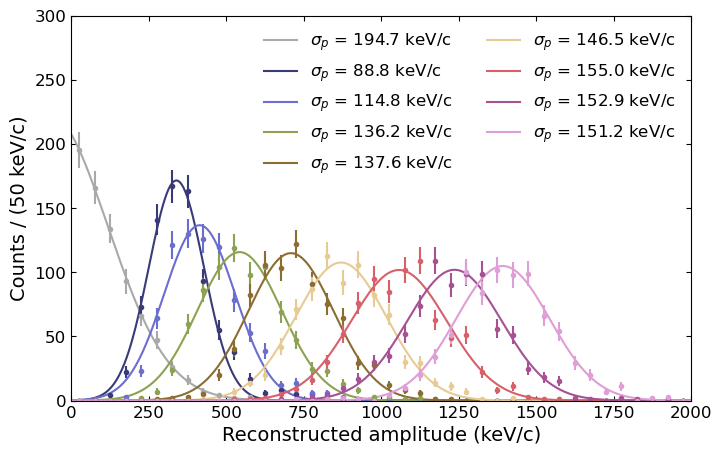

In [ ]:
pulseamps = pulse_amps_1e * 8

xx = np.linspace(0, np.max(bcs[0]), 1000)
amp2kev_all = pulseamps[-1] / gps[7][1]

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.colormaps.get_cmap('tab20b').resampled(8).colors

ax.errorbar(bcs[0]*amp2kev_all, hh_noise_nosearch[0], yerr=np.sqrt(hh_noise_nosearch[0]), fmt='.', color='darkgrey')
ax.plot(xx*amp2kev_all, utils.gauss(xx, *gps_nosearch[0]), label=fr'$\sigma_p$ = {gps_nosearch[0][2]*amp2kev_all:.1f} keV/c', color='darkgrey')

for i in range(8):
    ax.errorbar(bcs[0]*amp2kev_all, hhs[i], yerr=np.sqrt(hhs[i]), fmt='.', color=colors[i])
    ax.plot(xx*amp2kev_all, utils.gauss(xx, *gps[i]), color=colors[i], label=fr'$\sigma_p$ = {gps[i][2]*amp2kev_all:.1f} keV/c')

ax.legend(frameon=False, ncol=2)

ax.set_xlabel(r'Reconstructed amplitude (keV/c)')
ax.set_ylabel(fr'Counts / ({(bcs[0][1] - bcs[0][0]) * amp2kev_all:.0f} keV/c)')

ax.set_ylim(0, 300)
ax.set_xlim(0, 2000)


In [ ]:
pulseamps / np.asarray(gps).T[1]

array([1994.70804731, 4631.0064138 , 5931.64174855, 6365.87963025,
       6663.54355629, 6775.060436  , 6845.37482301, 7042.25563485])

In [50]:
ffs[0][1] - ffs[0][0]

np.float64(76.2939453125)

(1e-27, 1e-19)

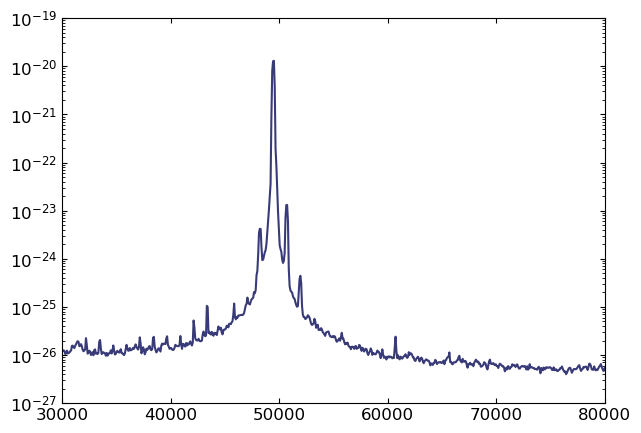

In [52]:
plt.plot(ffs[5], pps[5]*c_mv**2)
plt.yscale('log')

plt.xlim(30000, 80000)
plt.ylim(1e-27, 1e-19)

Derive calibration factor from electric calibration

In [44]:
## First derive the calibration factor for plotting
data_files = [r"E:\pulse_calibration\sphere_20250406\20250411_electric_calibration_2e-8mbar\20250411_d_m8e_163khz_4vpp_trapping_0.hdf5"]
c_mvs = utils.get_c_mv(data_files, [4], 163000*2*np.pi, passband=(161700, 164300), charge=8, n_chunk=6, efield=138)

c_mv = np.mean(c_mvs)
print('Calibration factor C_mv:', c_mv)

Calibration factor C_mv: 7.799071227643879e-08


In [72]:
amp2kev = 7055.26352068
npz_file = np.load(r'C:\Users\yuhan\dm_nanospheres\data_processed\pulse_shape/sphere_20250406_largepulse_shape_template_20v.npz')

zz_pulses = npz_file['zz_pulse']
pulse_shapes = npz_file['pulse_shape']

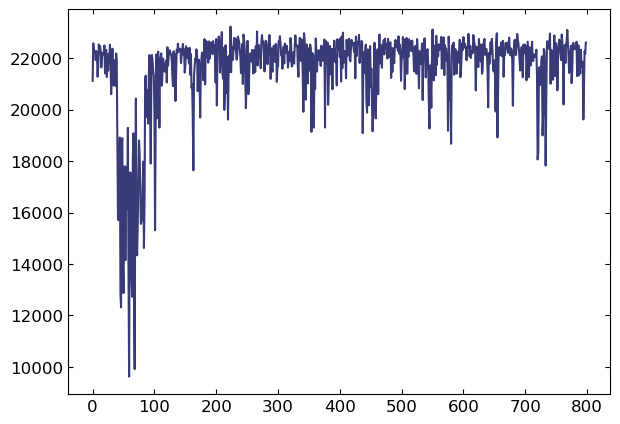

In [73]:
pulse_amps_kev = pulse_shapes.T[1500] * amp2kev
plt.plot(pulse_amps_kev)

In [75]:
np.std(pulse_amps_kev[pulse_amps_kev > 20000])

np.float64(595.1791061336821)

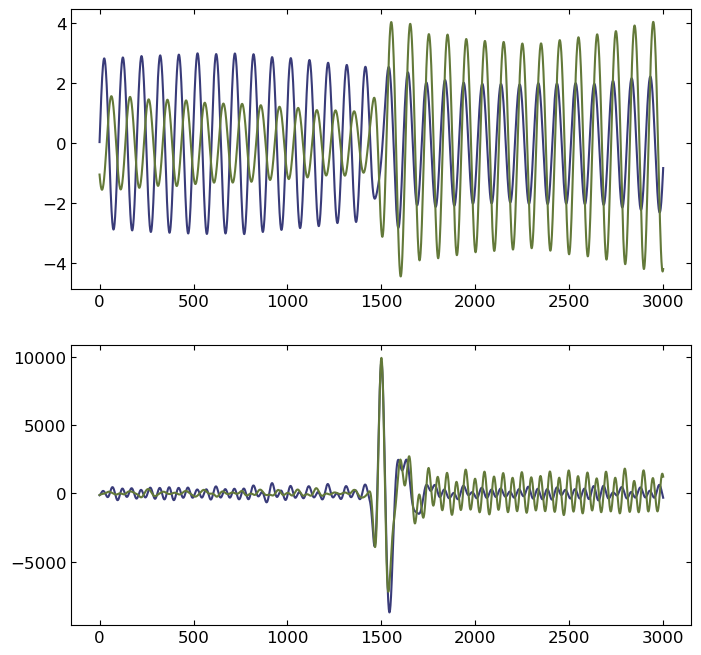

In [43]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))
for i in range(700):
    if np.abs(pulse_shapes[i][1500])*amp2kev > 12000:
        continue
    axes[1].plot(pulse_shapes[i] * amp2kev)
    axes[0].plot(zz_pulses[i] * c_mv / 1e-9)